# ノイズモデルを用いた計算

実際のIBM機を用いた計算の場合、量子ビットの接続性(connectivity)やノイズを考慮する必要がある。
Qiskitでは、FakeBackendが用意されており、実際の量子コンピュータの接続性やノイズを模擬したシミュレーションも可能である。

実際に実機にjobを投げる前に、こうしたFakeBackendを用いて回路やアルゴリズムの検証を行うことができる。

In [44]:
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime.fake_provider import FakeKyoto, FakeMumbaiV2, FakeValenciaV2
from qiskit.visualization import plot_gate_map
import matplotlib.pyplot as plt
import numpy as np

IBM-Kyoto (127 qubit)

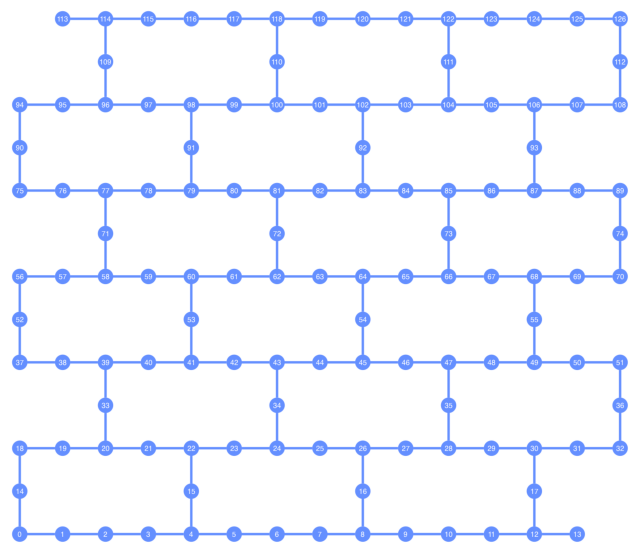

In [45]:
backend = FakeKyoto()
plot_gate_map(backend, figsize=(8, 8))

IBM-Mumbai (27 qubit)

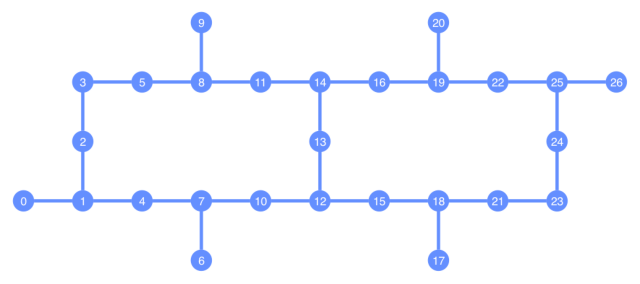

In [46]:
backend = FakeMumbaiV2()
plot_gate_map(backend, figsize=(8, 8))

## transpile

ユーザーが自前や用意された実装を用いてターゲットとなる系の状態作成回路を作成したとする。
一方でその回路は、実際の量子コンピュータの接続性やネイティブゲート(≒量子コンピュータが直接実行できるゲート)に対応していない場合がある。
このような場合に、回路をターゲットとなる量子コンピュータに適応させるために行うのがトランスパイル(transpile)、(あるいは単にcompileとも言う)である。

transpileの効果を確認するために、一粒子の励起・脱励起を表現するのに使えるGivens rotationを考えよう。
Givens rotationには幾つかの実装があり、生の回路のレベルでは、CNOTの数に違いが現れる。

1. Controlled-Ryを用いた直感的な実装 (例: Xanaduのpennylane)
2. GoogleのHF論文でも使用されたiSWAPを用いる実装
3. magic gateを用いた実装

これらはそれぞれ順に、

In [47]:
def Givens_magic(circ, i, j, theta):
    """
    Optimal quantum circuits for general two-qubit gates, based on [Phys. Rev. A 69, 032315 (2004)](https://doi.org/10.1103/PhysRevA.69.032315).
    It was used in e.g. [npj Quantum Information (2023) 9:60](https://www.nature.com/articles/s41534-023-00730-8)
    Maybe optimal in terms of number of CNOTs.
    """
    theta = theta / 2
    circ.s(i)
    circ.s(j)
    circ.h(j)
    circ.cx(j, i)
    circ.ry(theta, i)
    circ.ry(theta, j)
    circ.cx(j, i)
    circ.h(j)
    circ.sdg(i)
    circ.sdg(j)

def Givens_Xanadu(circ, i, j, theta):
    """
    Implementation given in paper by e.g. [Quantum 6, 742 (2022).](https://quantum-journal.org/papers/q-2022-06-20-742/)
    """
    theta_2 = theta / 2 
    circ.cx(i,j)
    circ.ry(theta_2, i)
    circ.cx(j,i)
    circ.ry(-theta_2, i)
    circ.cx(j,i)
    circ.cx(i,j)  

def apply_sqrt_iSWAP(qc, i, j):
    sqrt_iSWAP_matrix = np.array([
            [1, 0, 0, 0],
            [0, 1/np.sqrt(2), 1j/np.sqrt(2), 0],
            [0, 1j/np.sqrt(2), 1/np.sqrt(2), 0],
            [0, 0, 0, 1]]
    )
    qc.unitary(sqrt_iSWAP_matrix, [i, j], label='sqrt_iSWAP')

def Givens_iSWAP_Rz(circ, i, j, theta):
    """
    Givens rotation used in Google's HF paper, [Science 369, 1084 (2020)](DOI: 10.1126/science.abb9811).
    """
    theta = theta / 2
    apply_sqrt_iSWAP(circ, i, j)
    circ.rz(-theta, i)
    circ.rz(theta+np.pi, j)
    apply_sqrt_iSWAP(circ, i, j)
    circ.rz(np.pi, j)
    
def Givens_magic(circ, i, j, theta):
    """
    Optimal quantum circuits for general two-qubit gates, based on [Phys. Rev. A 69, 032315 (2004)](https://doi.org/10.1103/PhysRevA.69.032315).
    It was used in e.g. [npj Quantum Information (2023) 9:60](https://www.nature.com/articles/s41534-023-00730-8)
    Maybe optimal in terms of number of CNOTs.
    """
    theta = theta / 2
    circ.s(i)
    circ.s(j)
    circ.h(j)
    circ.cx(j, i)
    circ.ry(theta, i)
    circ.ry(theta, j)
    circ.cx(j, i)
    circ.h(j)
    circ.sdg(i)
    circ.sdg(j)

def Givens_Xanadu(circ, i, j, theta):
    """
    Implementation given in paper by e.g. [Quantum 6, 742 (2022).](https://quantum-journal.org/papers/q-2022-06-20-742/)
    """
    theta_2 = theta / 2 
    circ.cx(i,j)
    circ.ry(theta_2, i)
    circ.cx(j,i)
    circ.ry(-theta_2, i)
    circ.cx(j,i)
    circ.cx(i,j)  

まずは、connectivityやgate setを考えずに、transpileしてみよう。

Givens (Xanadu) + SWAP


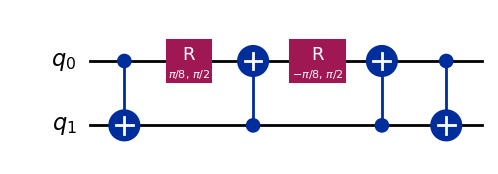

Transpiled:


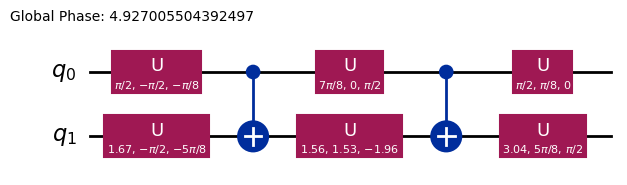

Givens (magic) + SWAP


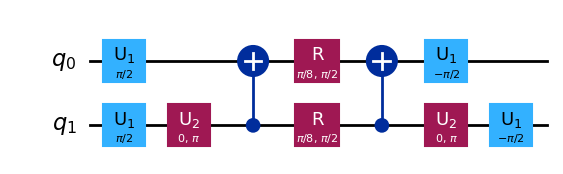

Transpiled:


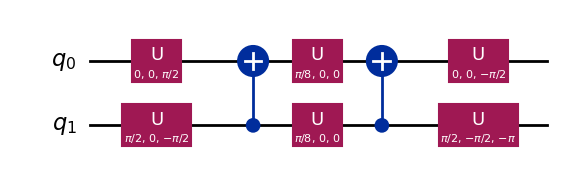

Givens (Google) + SWAP


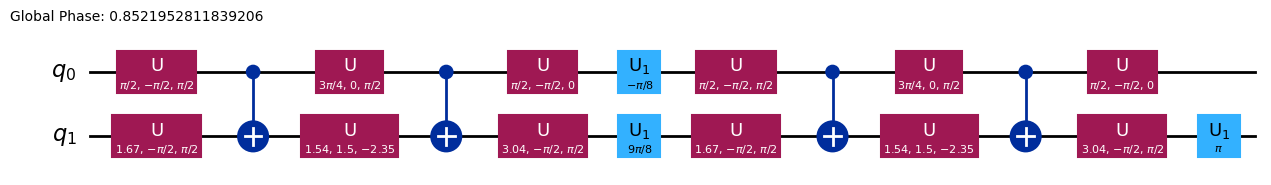

Transpiled:


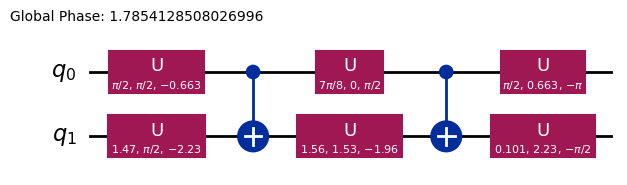

In [48]:
print("Givens (Xanadu) + SWAP")
qc_1 = QuantumCircuit(2)
Givens_Xanadu(qc_1, 0, 1, np.pi / 4)
qc_1 = qc_1.decompose()
display(qc_1.draw('mpl'))
qc_1 = transpile(qc_1, optimization_level=2).decompose(reps=2)
print("Transpiled:")
display(qc_1.draw('mpl'))

print("Givens (magic) + SWAP")
qc_2 = QuantumCircuit(2)
Givens_magic(qc_2, 0, 1, np.pi / 4)
qc_2 = qc_2.decompose()
display(qc_2.draw('mpl'))
qc_2 = transpile(qc_2, optimization_level=2)       
print("Transpiled:")
display(qc_2.decompose(reps=2).draw('mpl'))

print("Givens (Google) + SWAP")
qc_3 = QuantumCircuit(2)
Givens_iSWAP_Rz(qc_3, 0, 1, np.pi / 4)
qc_3 = qc_3.decompose()
display(qc_3.draw('mpl'))
qc_3 = transpile(qc_3, optimization_level=2)       
print("Transpiled:")
display(qc_3.decompose(reps=2).draw('mpl'))



いずれの場合も、3つの`CNOT`と6つの`U`(1量子ビット一般回転ゲート)に分解されていることがわかる。

ではこれらの回路を、実際の量子コンピュータの接続性やネイティブゲートに対応させるためにbackendを指定してtranspileしてみよう。
量子ビット数の多いバックエンドを指定すると回路図が冗長になるので、5量子ビットの`FakeValenciaV2`を用いることにして...

Givens (Xanadu) + SWAP; transpiled


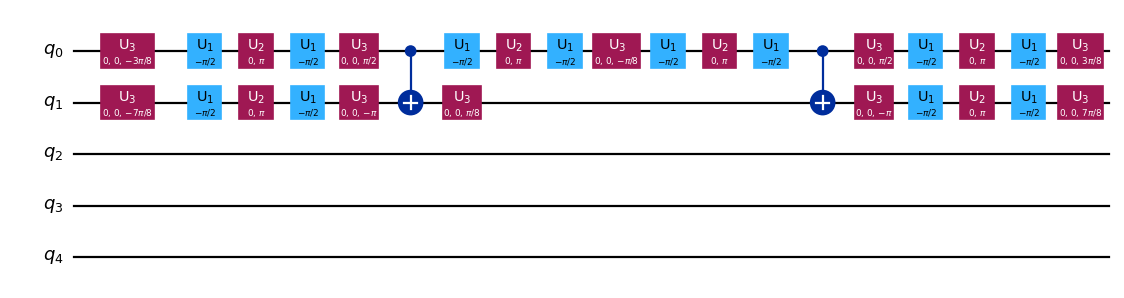

Givens (magic) + SWAP; transpiled


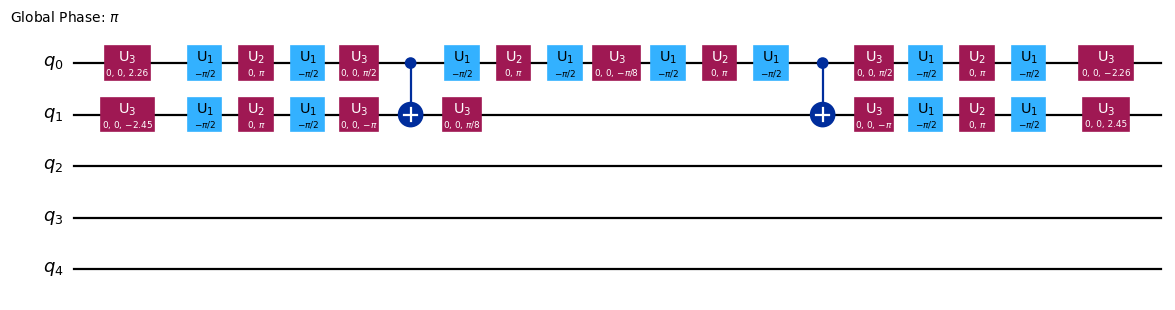

Givens (Google) + SWAP; transpiled


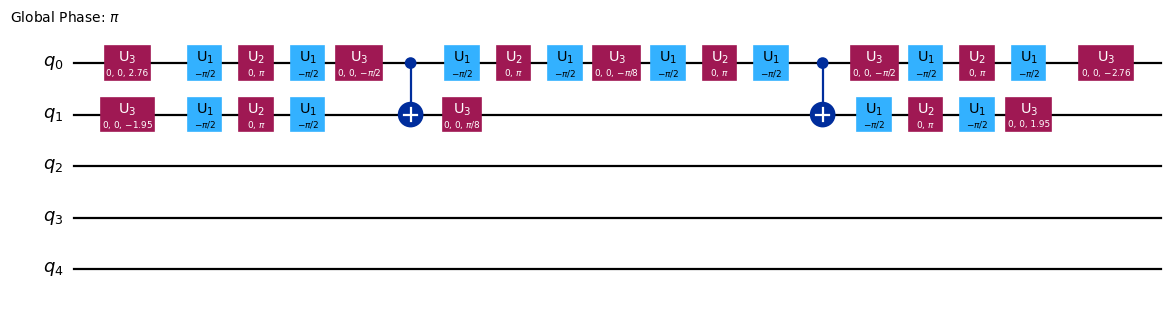

In [50]:
backend = FakeValenciaV2()

print("Givens (Xanadu) + SWAP; transpiled")
qc_1 = QuantumCircuit(2)
Givens_Xanadu(qc_1, 0, 1, np.pi / 4)
qc_1 = transpile(qc_1, optimization_level=2, backend=backend).decompose(reps=2)
display(qc_1.draw('mpl', scale=0.8))

print("Givens (magic) + SWAP; transpiled")
qc_2 = QuantumCircuit(2)
Givens_magic(qc_2, 0, 1, np.pi / 4)
qc_2 = transpile(qc_2, optimization_level=2, backend=backend).decompose(reps=2)
display(qc_2.draw('mpl', scale=0.8))

print("Givens (Google) + SWAP; transpiled")
qc_3 = QuantumCircuit(2)
Givens_iSWAP_Rz(qc_3, 0, 1, np.pi / 4)
qc_3 = transpile(qc_3, optimization_level=2, backend=backend).decompose(reps=2)
display(qc_3.draw('mpl', scale=0.8))



## 簡単な回路の測定

ノイズなし/ノイズありの回路を用意して、実際に測定してみよう。レイアウトはFakeValenciaV2を用いる。



In [105]:
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2

nshot = 1024

sampler = SamplerV2()
qc = QuantumCircuit(2)
qc.x(0)
Givens_Xanadu(qc, 0, 1, 2*np.pi / 4)
qc = transpile(qc, optimization_level=2)
qc.measure_all()
job = sampler.run([qc.decompose(reps=5)], shots=nshot)
results = job.result()
counts = results[0].data.meas.get_counts()

device_backend = FakeTorino()
sampler = AerSimulator.from_backend(device_backend)
tqc = transpile(qc, sampler)
job = sampler.run([tqc], shots=nshot)
results = job.result()
counts_ = results.get_counts()


In [106]:
counts

{'01': 500, '10': 524}

In [107]:
counts_

{'01': 479, '00': 9, '11': 11, '10': 525}